# Exercício 3 - Classificação

Aluno: Fabio Kishino

### Parte 1 - Classificação

1- Utilize o dataset “titanic.csv”, disponível no moodle. Considere 70% das instâncias para treino e 30% para validação. Construa um modelo utilizando Árvore de Decisão para prever se uma pessoa sobreviveu ou não.<br>

* a) Mostre a árvore encontrada.
* b) Qual a acurácia do modelo obtida com os dados de validação?

In [23]:
import seaborn as sns

df = sns.load_dataset("titanic")

# A feature 'alive' foi removida, pois é redundante com 'survived' e afeta o modelo
df.drop(['age', 'embarked', 'deck', 'embark_town', 'alive'], axis=1, inplace=True)

from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
le = LabelEncoder()

categorical_columns = ['sex', 'class', 'who']
for col in categorical_columns:
    df_encoded[col] = le.fit_transform(df_encoded[col]).astype('int8')

df_encoded.info()
df_encoded.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    891 non-null    int64  
 1   pclass      891 non-null    int64  
 2   sex         891 non-null    int8   
 3   sibsp       891 non-null    int64  
 4   parch       891 non-null    int64  
 5   fare        891 non-null    float64
 6   class       891 non-null    int8   
 7   who         891 non-null    int8   
 8   adult_male  891 non-null    bool   
 9   alone       891 non-null    bool   
dtypes: bool(2), float64(1), int64(4), int8(3)
memory usage: 39.3 KB


,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alone
0,0,3,1,1,0,7.2500,2,1,True,False
1,1,1,0,1,0,71.2833,0,2,False,False
2,1,3,0,0,0,7.9250,2,2,False,True
3,1,1,0,1,0,53.1000,0,2,False,False
4,0,3,1,0,0,8.0500,2,1,True,True


In [24]:
# Separação do dataset
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df_encoded, test_size=0.3, random_state=42)
df_train

,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alone
445,1,1,1,0,2,81.8583,0,0,False,False
650,0,3,1,0,0,7.8958,2,1,True,True
172,1,3,0,1,1,11.1333,2,0,False,False
450,0,2,1,1,2,27.7500,1,1,True,False
314,0,2,1,1,1,26.2500,1,1,True,False
...,...,...,...,...,...,...,...,...,...,...
106,1,3,0,0,0,7.6500,2,2,False,True
270,0,1,1,0,0,31.0000,0,1,True,True
860,0,3,1,2,0,14.1083,2,1,True,False
435,1,1,0,1,2,120.0000,0,0,False,False


[]

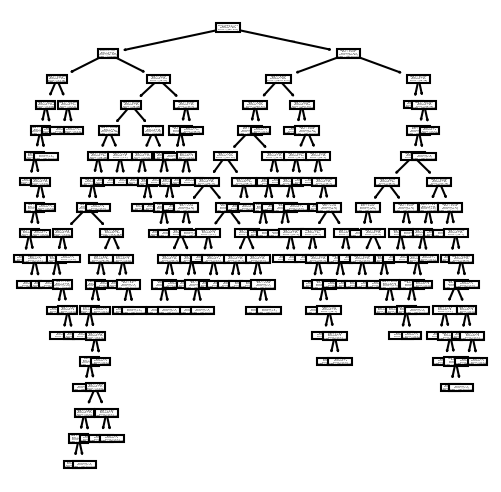

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt

model = tree.DecisionTreeClassifier()

# X contém apenas features, y contém o rótulo
X = df_train[['pclass', 'sex', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male', 'alone']]
y = df_train['survived']

model.fit(X, y)

fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=150)
tree.plot_tree(model, feature_names = X.columns, class_names=['Not Survived', 'Survived']) 
plt.plot()


In [26]:
# Acurácia
X_test = df_test[["pclass", "sex", "sibsp", "parch", "fare", "class", "who", "adult_male", "alone"]]

print(X_test)

y_test = df_test['survived']
model.score(X_test, y_test)

     pclass  sex  sibsp  parch     fare  class  who  adult_male  alone
709       3    1      1      1  15.2458      2    1        True  False
439       2    1      0      0  10.5000      1    1        True   True
840       3    1      0      0   7.9250      2    1        True   True
720       2    0      0      1  33.0000      1    0       False  False
39        3    0      1      0  11.2417      2    0       False  False
..      ...  ...    ...    ...      ...    ...  ...         ...    ...
821       3    1      0      0   8.6625      2    1        True   True
633       1    1      0      0   0.0000      0    1        True   True
456       1    1      0      0  26.5500      0    1        True   True
500       3    1      0      0   8.6625      2    1        True   True
430       1    1      0      0  26.5500      0    1        True   True

[268 rows x 9 columns]


0.8097014925373134

2- Considere ainda uma árvore de decisão para classificar se um indivíduo sobreviveu ou não com base no dataset “titanic.csv”. Qual o resultado médio de acurácia utilizando a estratégia de validação cruzada 10-fold? Discuta os resultados.

In [34]:
from sklearn.model_selection import cross_val_score

X = df_train[['pclass', 'sex', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male', 'alone']]
y = df_train['survived']

scores = cross_val_score(model, X, y, cv=5)

tree_model = tree.DecisionTreeClassifier()

scores = cross_val_score(tree_model, X, y, cv=10)

print("Acurácia média: %.2f%%" % (scores.mean() * 100))
print("Desvio padrão: %.4f" % scores.std())

Acurácia média: 82.35%
Desvio padrão: 0.0446


3- Ainda considerando o dataset “titanic.csv”, construa um modelo utilizando k-NN para prever se uma pessoa sobreviveu ou não. Considere diferentes valores de k vizinhos: k={2,3,4,5,6,7}. Houve variação significativa nos diferentes modelos testados? Algum deles foi melhor do que a estratégia baseada em árvore de decisão?

In [37]:
# Knn
from sklearn.neighbors import KNeighborsClassifier

k_neighbors = [2,3,4,5,6,7]

for k in k_neighbors:
    neigh = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(neigh, X, y, cv=10)
    print("Acurácia média para k=%d: %.2f%%" % (k, scores.mean() * 100))
    print("Desvio padrão: %.4f \n" % scores.std())


Acurácia média para k=2: 73.52%
Desvio padrão: 0.0352 

Acurácia média para k=3: 75.93%
Desvio padrão: 0.0690 

Acurácia média para k=4: 74.32%
Desvio padrão: 0.0639 

Acurácia média para k=5: 75.77%
Desvio padrão: 0.0552 

Acurácia média para k=6: 73.51%
Desvio padrão: 0.0380 

Acurácia média para k=7: 75.61%
Desvio padrão: 0.0524 



### Parte 2 – Agrupamento

4 - Considere as Latitudes e Longitudes dos estabelecimentos do dataset fornecido para o desafio. Utilizando o DBSCAN, faça o que é pedido abaixo. <br>
- a) Agrupe os estabelecimentos que são populares. Varie os valores de eps e min_samples. Escolha uma combinação que julgue produzir um resultado interessante. Justifique a sua escolha.
- b) Agrupe os estabelecimentos que não são populares. Varie os valores de eps e min_samples. Escolha uma combinação que julgue produzir um resultado interessante. Justifique a sua escolha.
- c) Visualize os clusters encontrados para ambos os casos. Existe alguma tendência de concentração em determinadas partes da cidade? Faça uma breve análise dos resultados encontrados.

In [ ]:
# Code here
